# 24RB1003 松澤颯斗

# 演習：PCA vs ランダム射影

### 1. データ行列 $X$ を**中心化**する  ($X \leftarrow X - \bar{X}$，$\bar{X}$ は各特徴量の平均)．

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# データセットの読み込み
digits = load_digits()
X = digits.data
y = digits.target
X.shape, y.shape

((1797, 64), (1797,))

In [13]:
# X の最初の5行を表示する
X[:5]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.,  0.,  0.,  0., 11., 16.,
         9.,  0.,  0.,  0.,  0.,  3., 15., 16.,  6.,  0.,  0.,  0.,  7.,
        15., 16., 16.,  2.,  0.,  0.,  0.,  0.,  1., 16., 16.,  3.,  0.,
         0.,  0.,  0.,  1., 16., 16.,  6.,  0.,  0.,  0.,  0.,  1., 16.,
        16.,  6.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,  0.,  0.],
       [ 0.,  0.,  0.,  4., 15., 12.,  0.,  0.,  0.,  0.,  3., 16., 15.,
        14.,  0.,  0.,  0.,  0.,  8., 13.,  8., 16.,  0.,  0.,  0.,  0.,
         1.,  6., 15., 11.,  0.,  0.,  0.,  1.,  8., 13., 15.,  1.,  0.,
         0.,  0.,  9., 16., 16.,  5.,  0.,  0.,  0.,  0.,  

In [14]:
# y の値を確認する
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [15]:
# X を中心化する
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

### 2. **PCA**  (`sklearn.decomposition.PCA`, `n_components=2`) で 2 次元に射影し，数字ラベルで色分けした散布図を描く．

In [16]:
# PCA を適用する
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_centered)
X_pca.shape

(1797, 2)

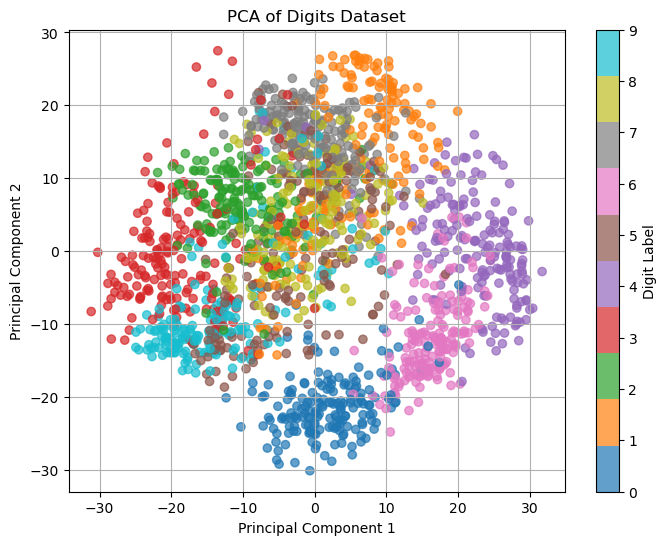

In [17]:
# PCAの結果を散布図で可視化する
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Digits Dataset')
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.grid()
plt.show()

### 3. **ランダム射影**  (Step 1 の**中心化済みデータ**に対して，$A_{ij} \sim N(0, 1/2) \ \text{i.i.d.}, \quad Y = XA^\top$)でも同様に 2 次元散布図を描く．

In [18]:
# ランダムな行列 A を作成する
A = np.random.normal(loc=0, scale=1/np.sqrt(2), size=(2, X_centered.shape[1]))
A.shape


(2, 64)

In [19]:
# 中心化したデータをランダムな行列 A に射影する
Y = X_centered @ A.T
Y.shape

(1797, 2)

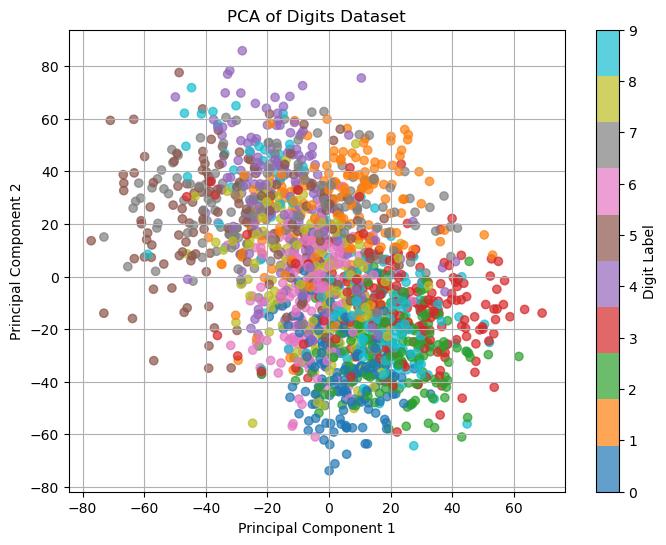

In [20]:
# ランダム射影の結果を散布図で可視化する
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Y[:, 0], Y[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Digits Dataset')
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.grid()
plt.show()

### 4. 2 つの図を並べ，クラスの分離の違いをコメントする．

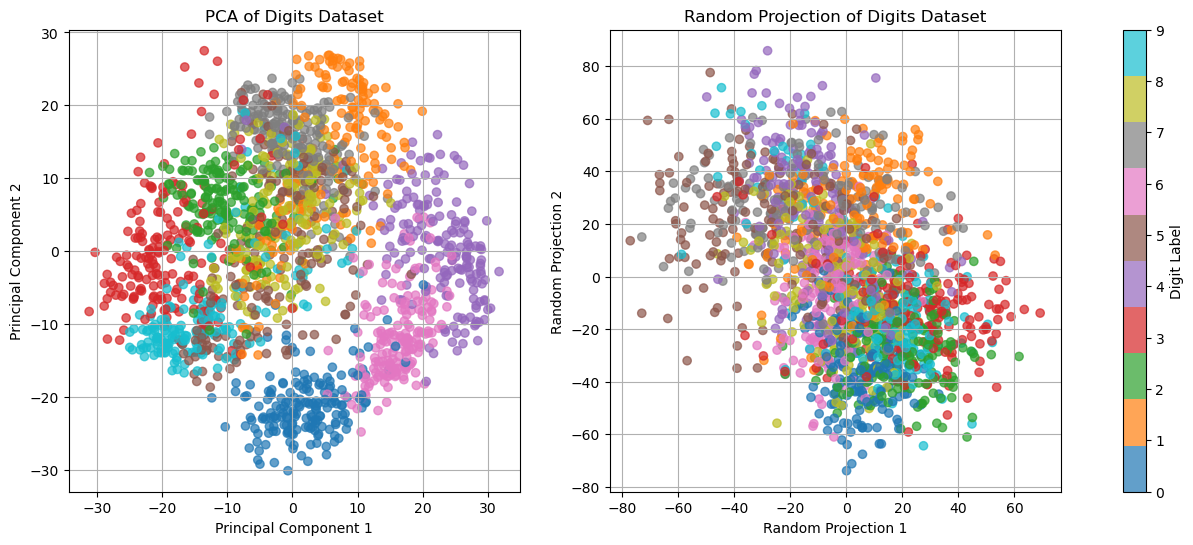

In [21]:
# 2つの図を並べる
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.set_title('PCA of Digits Dataset')
ax1.grid()

scatter2 = ax2.scatter(Y[:, 0], Y[:, 1], c=y, cmap='tab10', alpha=0.7)
ax2.set_xlabel('Random Projection 1')
ax2.set_ylabel('Random Projection 2')
ax2.set_title('Random Projection of Digits Dataset')
ax2.grid()

fig.colorbar(scatter1, ax=[ax1, ax2], ticks=range(10), label='Digit Label')
plt.show()

#### PCA の結果
- 数字ラベルごとに，ある程度まとまったクラスタが確認できる．
- いくつかの数字は，他の数字と比較的分離している．
- PCA はデータの分散が大きい方向を選んで射影するため，データの構造が見えやすい．
- そのため，数字クラスごとの違いが比較的よく表れている．
---
#### ランダム射影の結果
- 多くの点が重なっており，クラスごとの分離は PCA より不明瞭である．
- 射影方向をランダムに決めるため，数字を分けるのに有効な方向が選ばれるとは限らない．
- その結果，異なる数字の点が同じ領域に混ざりやすくなっている．
- 一部にはまとまりも見られるが，全体としてクラスタの区別は難しい．

# 考察

今回の結果から，`digits` データセットを 2 次元に可視化する場合は PCA の方がランダム射影よりもクラスの分離を捉えやすいことが分かった．PCA はデータの情報量をなるべく保つように射影するため，数字ごとの特徴が平面上に現れやすい．一方で，ランダム射影はランダムな方向へ写すため，可視化したときのクラス構造は PCA ほど明確にはならない．したがって，2 次元でデータの構造を理解したい場合には，ランダム射影よりも PCA の方が適していると考えられる．

# AI使用について

Gemini Guided Learningを使用して，データの生成方法や可視化方法などの一連の実装方法について質問した．AI に直接コードを生成させることはせず，実装の方針や考え方のヒントのみをもらい，それをもとに自身でコードを作成した．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．